## IMPLEMENTING A SIMPLIFIED ATTENTION MECHANISM

In [1]:
import torch

In [2]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [3]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

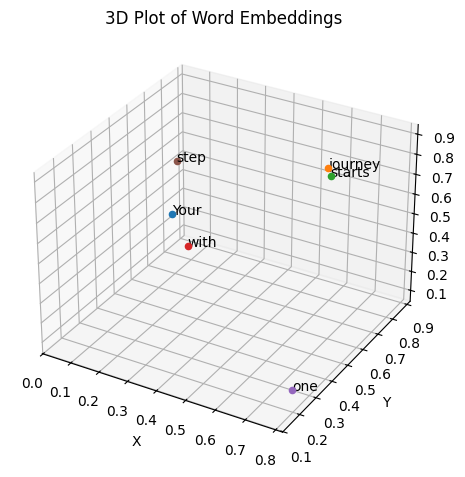

In [4]:
words = ["Your", "journey", "starts", "with", "one", "step"]

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize = 10)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("3D Plot of Word Embeddings")
plt.tight_layout()
plt.show()

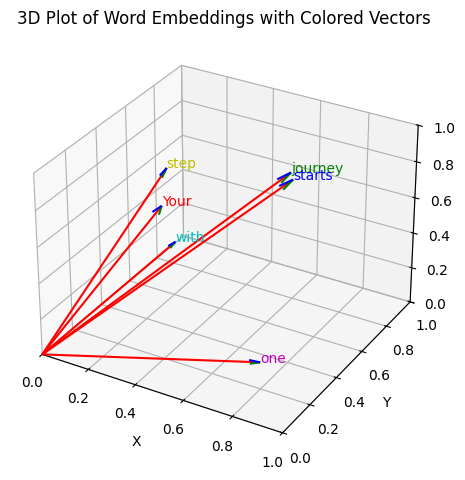

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

colors = ["r", "g", "b", "c", "m", "y"]

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color = colors, arrow_length_ratio = 0.05)
    ax.text(x, y, z, word, fontsize = 10, color = color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.tight_layout()
plt.show()

In [6]:
query = inputs[1]

attn_score_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_score_2[i] = torch.dot(x_i, query)

print(attn_score_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [7]:
attn_weights_2_tmp = attn_score_2 / attn_score_2.sum()

print(f"Attention Weights :- {attn_weights_2_tmp}")
print(f"Sum :- {attn_weights_2_tmp.sum()}")

Attention Weights :- tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum :- 1.0000001192092896


In [8]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_score_2)

print(f"Attention weights :- {attn_weights_2_naive}")
print(f"Sum :- {attn_weights_2_naive.sum()}")

Attention weights :- tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum :- 1.0


In [9]:
attn_weights_2 = torch.softmax(attn_score_2, dim=0)
print(f"Attention weights :- {attn_weights_2}")
print(f"Sum :- {attn_weights_2.sum()}")

Attention weights :- tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum :- 1.0


In [10]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


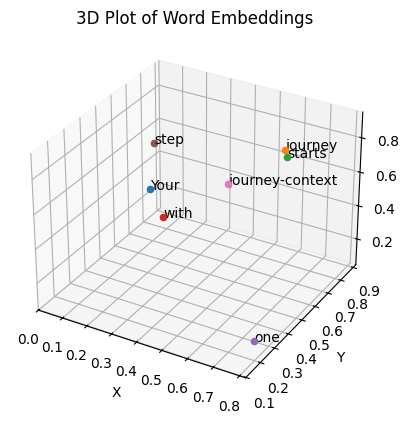

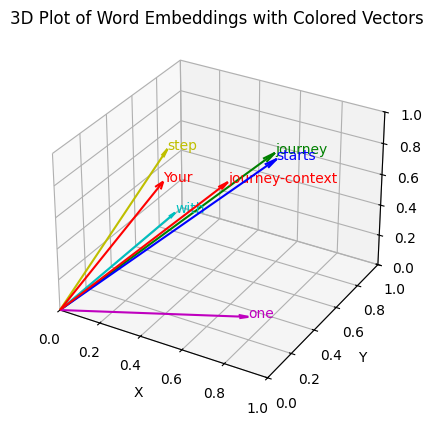

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)

words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

In [12]:
attn_scores = torch.empty(inputs.shape[0], inputs.shape[0])

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


In [13]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


In [14]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.1792, 0.1713, 0.1692, 0.1061, 0.1042, 0.1240, 0.1459],
        [0.1180, 0.2026, 0.1986, 0.1056, 0.0921, 0.1346, 0.1486],
        [0.1184, 0.2017, 0.1981, 0.1058, 0.0943, 0.1332, 0.1485],
        [0.1223, 0.1768, 0.1744, 0.1246, 0.1077, 0.1467, 0.1476],
        [0.1305, 0.1675, 0.1689, 0.1169, 0.1607, 0.1108, 0.1446],
        [0.1180, 0.1861, 0.1813, 0.1211, 0.0842, 0.1615, 0.1478],
        [0.1277, 0.1889, 0.1860, 0.1121, 0.1011, 0.1359, 0.1483]])


In [15]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [16]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4420, 0.6016, 0.5774],
        [0.4419, 0.6515, 0.5683],
        [0.4429, 0.6499, 0.5673],
        [0.4321, 0.6330, 0.5536],
        [0.4635, 0.5997, 0.5326],
        [0.4213, 0.6505, 0.5651],
        [0.4397, 0.6372, 0.5635]])


In [17]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


## IMPLEMENTING SELF ATTENTION WITH TRAINABLE WEIGHTS

In [18]:
import torch

In [19]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]], # step     (x^6)
)

In [20]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [21]:
torch.manual_seed(123)

w_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
w_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
w_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [22]:
print(w_query)
print(w_key)
print(w_value)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [23]:
query_2 = x_2 @ w_query
key_2 = x_2 @ w_key
value_2 = x_2 @ w_value

In [24]:
print(query_2)
print(key_2)
print(value_2)

tensor([0.4306, 1.4551])
tensor([0.4433, 1.1419])
tensor([0.3951, 1.0037])


In [25]:
keys = inputs @ w_key
querys = inputs @ w_query
values = inputs @ w_value

In [26]:
print(keys.shape)
print(querys.shape)
print(values.shape)

torch.Size([6, 2])
torch.Size([6, 2])
torch.Size([6, 2])


In [27]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [28]:
attn_score_2 = query_2 @ keys.T
print(attn_score_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [29]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_score_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [30]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


## IMPLEMENTING A COMPACT SELF ATTENTION PYTHON CLASS

In [31]:
import torch.nn as nn

In [32]:
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.w_query = nn.Parameter(torch.rand(d_in, d_out))
        self.w_key = nn.Parameter(torch.rand(d_in, d_out))
        self.w_value = nn.Parameter(torch.rand(d_in, d_out))
    
    def forward(self, x):
        keys = x @ self.w_key
        queries = x @ self.w_query
        values = x @ self.w_value

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values

        return context_vec

In [33]:
torch.manual_seed(123)

sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [34]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias = False):
        super().__init__()
        self.w_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_value = nn.Linear(d_in, d_out, bias = qkv_bias)
    
    def forward(self, x):
        keys = self.w_key(x)
        queries = self.w_query(x)
        values = self.w_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values

        return context_vec

In [35]:
torch.manual_seed(123)

sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


## HIDING FUTURE WORDS WITH CAUSAL ATTENTION

In [36]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [37]:
queries = sa_v2.w_query(inputs)
keys = sa_v2.w_query(inputs)

attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)

print(attn_weights)

tensor([[0.1895, 0.1660, 0.1663, 0.1562, 0.1674, 0.1547],
        [0.1694, 0.1690, 0.1690, 0.1633, 0.1652, 0.1642],
        [0.1696, 0.1690, 0.1689, 0.1632, 0.1652, 0.1640],
        [0.1642, 0.1683, 0.1682, 0.1664, 0.1654, 0.1673],
        [0.1732, 0.1675, 0.1675, 0.1628, 0.1663, 0.1627],
        [0.1623, 0.1688, 0.1687, 0.1670, 0.1650, 0.1683]],
       grad_fn=<SoftmaxBackward0>)


In [38]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [39]:
masked_simple = attn_weights * mask_simple
print(masked_simple)

tensor([[0.1895, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1694, 0.1690, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1696, 0.1690, 0.1689, 0.0000, 0.0000, 0.0000],
        [0.1642, 0.1683, 0.1682, 0.1664, 0.0000, 0.0000],
        [0.1732, 0.1675, 0.1675, 0.1628, 0.1663, 0.0000],
        [0.1623, 0.1688, 0.1687, 0.1670, 0.1650, 0.1683]],
       grad_fn=<MulBackward0>)


In [40]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5006, 0.4994, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3342, 0.3329, 0.3328, 0.0000, 0.0000, 0.0000],
        [0.2462, 0.2523, 0.2521, 0.2494, 0.0000, 0.0000],
        [0.2069, 0.2000, 0.2001, 0.1944, 0.1986, 0.0000],
        [0.1623, 0.1688, 0.1687, 0.1670, 0.1650, 0.1683]],
       grad_fn=<DivBackward0>)


In [41]:
print(attn_scores)

tensor([[ 0.2822,  0.0954,  0.0974,  0.0091,  0.1070, -0.0049],
        [ 0.0954,  0.0921,  0.0917,  0.0437,  0.0595,  0.0509],
        [ 0.0974,  0.0917,  0.0914,  0.0431,  0.0598,  0.0500],
        [ 0.0091,  0.0437,  0.0431,  0.0279,  0.0193,  0.0355],
        [ 0.1070,  0.0595,  0.0598,  0.0193,  0.0497,  0.0186],
        [-0.0049,  0.0509,  0.0500,  0.0355,  0.0186,  0.0462]],
       grad_fn=<MmBackward0>)


In [42]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal = 1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[ 0.2822,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.0954,  0.0921,    -inf,    -inf,    -inf,    -inf],
        [ 0.0974,  0.0917,  0.0914,    -inf,    -inf,    -inf],
        [ 0.0091,  0.0437,  0.0431,  0.0279,    -inf,    -inf],
        [ 0.1070,  0.0595,  0.0598,  0.0193,  0.0497,    -inf],
        [-0.0049,  0.0509,  0.0500,  0.0355,  0.0186,  0.0462]],
       grad_fn=<MaskedFillBackward0>)


### MASKING ADDITIONAL ATTENTION WEIGHTS WITH DROPOUT

In [43]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [44]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[0.3789, 0.3320, 0.0000, 0.3124, 0.3348, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.3266, 0.0000, 0.3283],
        [0.3393, 0.3379, 0.3378, 0.3265, 0.0000, 0.3281],
        [0.0000, 0.3366, 0.3365, 0.0000, 0.0000, 0.3347],
        [0.0000, 0.3350, 0.0000, 0.3256, 0.0000, 0.3254],
        [0.0000, 0.3376, 0.3374, 0.3340, 0.3300, 0.0000]],
       grad_fn=<MulBackward0>)


### IMPLEMENTING A COMPACT CAUSAL ATTENTION CLASS

In [45]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [46]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias = False):
        super().__init__()
        self.d_out = d_out
        self.w_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.w_value = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.w_key(x)
        queries = self.w_query(x)
        values = self.w_value(x)

        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec

In [47]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)

print(f"context_vecs.shape :- {context_vecs.shape}")

context_vecs.shape :- torch.Size([2, 6, 2])


In [48]:
print(context_vecs)

tensor([[[-0.5337, -0.1051],
         [-0.5323, -0.1080],
         [-0.5323, -0.1079],
         [-0.5297, -0.1076],
         [-0.5311, -0.1066],
         [-0.5299, -0.1081]],

        [[-0.5337, -0.1051],
         [-0.5323, -0.1080],
         [-0.5323, -0.1079],
         [-0.5297, -0.1076],
         [-0.5311, -0.1066],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


## EXTENDING SINGLE HEAD ATTENTION TO MULTI-HEAD ATTENTION

In [49]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias = False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
            for _ in range(num_heads)]
        )
    
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [50]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [51]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


### IMPLEMENTING MULTI-HEAD ATTENTION WITH WEIGHT SPLITS

In [62]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bais = False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.w_query = nn.Linear(d_in, d_out, bias = qkv_bais)
        self.w_key = nn.Linear(d_in, d_out, bias = qkv_bais)
        self.w_value = nn.Linear(d_in, d_out, bias = qkv_bais)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.w_key(x)
        queries = self.w_query(x)
        values = self.w_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim) 
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim) 

        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        attn_scores = queries @ keys.transpose(2,3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2) 

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

In [63]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573], #A
[0.8993, 0.0390, 0.9268, 0.7388],
[0.7179, 0.7058, 0.9156, 0.4340]],
[[0.0772, 0.3565, 0.1479, 0.5331],
[0.4066, 0.2318, 0.4545, 0.9737],
[0.4606, 0.5159, 0.4220, 0.5786]]]])

In [64]:
print(a @ a.transpose(2, 3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [65]:
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)
second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


In [66]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.3417,  0.0230,  0.3356,  0.5395, -0.1244,  0.3274],
         [-0.3411,  0.0262,  0.3339,  0.5371, -0.1248,  0.3260],
         [-0.3411,  0.0262,  0.3339,  0.5371, -0.1248,  0.3260],
         [-0.3422,  0.0243,  0.3339,  0.5372, -0.1241,  0.3258],
         [-0.3419,  0.0239,  0.3337,  0.5382, -0.1243,  0.3259],
         [-0.3421,  0.0250,  0.3340,  0.5368, -0.1242,  0.3258]],

        [[-0.3417,  0.0230,  0.3356,  0.5395, -0.1244,  0.3274],
         [-0.3411,  0.0262,  0.3339,  0.5371, -0.1248,  0.3260],
         [-0.3411,  0.0262,  0.3339,  0.5371, -0.1248,  0.3260],
         [-0.3422,  0.0243,  0.3339,  0.5372, -0.1241,  0.3258],
         [-0.3419,  0.0239,  0.3337,  0.5382, -0.1243,  0.3259],
         [-0.3421,  0.0250,  0.3340,  0.5368, -0.1242,  0.3258]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 6])
